In [220]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

SEED = 42
np.random.seed(SEED)

# Algoritmo de *rejection sampling*
- Sea $\tilde{p}(x) = e^{-(x-2)^2} + 0.5e^{-(x+1)^2}$ y $q = \text{Uniforme}(x)$.
- Responder a las siguientes preguntas:

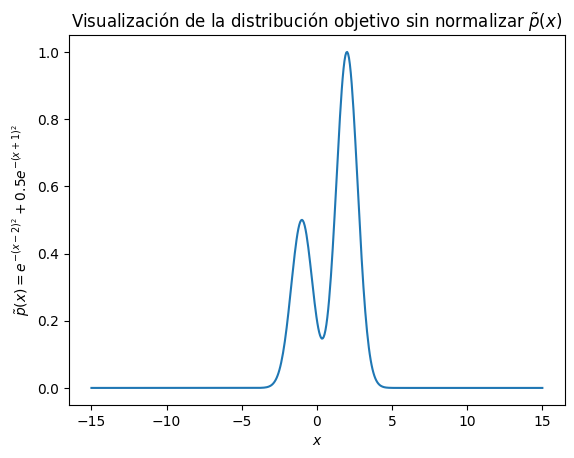

In [221]:
def p_tilde(x):
    return np.exp(-(x - 2)**2) + 0.5 * np.exp(-(x + 1)**2)

x = np.linspace(-15, 15, 500)
y_p_tilde = p_tilde(x)

plt.plot(x, y_p_tilde)
plt.xlabel(r"$x$")
plt.ylabel(r"$\tilde{p}(x) = e^{-(x-2)^2} + 0.5e^{-(x+1)^2}$")
plt.title(r"Visualización de la distribución objetivo sin normalizar $\tilde{p}(x)$")
plt.show()

1. ¿Cuál debería ser el soporte de $q$?
- Como se puede observar en la representación de $\tilde{p}(x)$, lo más adecuado es que el soporte de $q$ sea $[-5, 5]$.

In [222]:
def q(x):
    return uniform.pdf(x, loc=-5, scale=10)

2. ¿Cúal debería ser el valor mínimo de $C$?

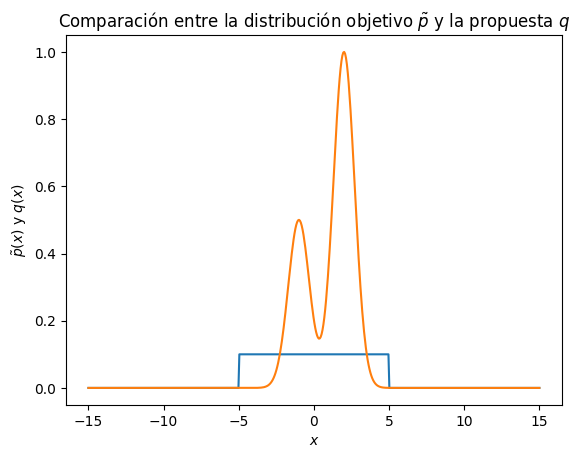

In [223]:
y_q = q(x)
plt.plot(x, y_q)
plt.plot(x, y_p_tilde)
plt.xlabel(r"$x$")
plt.ylabel(r"$\tilde{p}(x)$ y $q(x)$")
plt.title(r"Comparación entre la distribución objetivo $\tilde{p}$ y la propuesta $q$")
plt.show()

- Teniendo en cuenta que el soporte de nuestra distribución propuesta es $[-5, 5]$ y que, por tanto, $q(x) = 0.1, \forall x \in [-5, 5]$, tendríamos que multiplicar el output por 10 como mínimo. Entonces, asignamos $C = 10$.

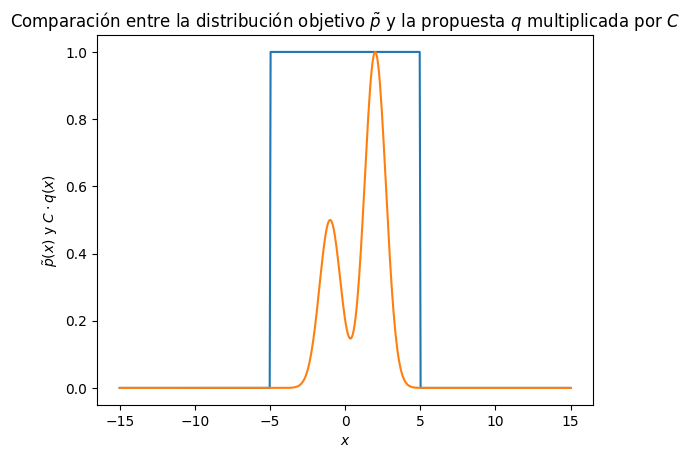

In [224]:
C = 10
y_C_q = C * q(x)
plt.plot(x, y_C_q)
plt.plot(x, y_p_tilde)
plt.xlabel(r"$x$")
plt.ylabel(r"$\tilde{p}(x)$ y $C \cdot q(x)$")
plt.title(r"Comparación entre la distribución objetivo $\tilde{p}$ y la propuesta $q$ multiplicada por $C$")
plt.show()

3. Generar $N$ muestras de $p$.

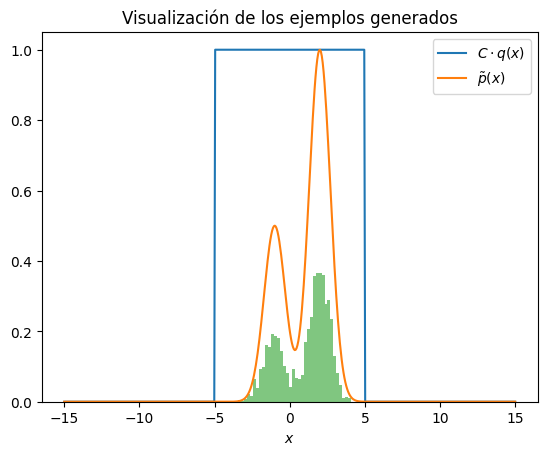

In [225]:
def rejection_sampling(f, Cq_pdf, num_samples):
    samples = []
    while len(samples) < num_samples:
        x_i = np.random.uniform(-5, 5)
        u = np.random.uniform(0, max(Cq_pdf))
        if u < f(x_i):
            samples.append(x_i)
    return np.array(samples)

N = 2000
p_samples = rejection_sampling(p_tilde, y_C_q, N)

plt.plot(x, y_C_q, label=r"$C \cdot q(x)$")
plt.plot(x, y_p_tilde, label=r"$\tilde{p}(x)$")
plt.hist(p_samples, bins=40, density=True, alpha=0.6)
plt.xlabel(r"$x$")
plt.title(r"Visualización de los ejemplos generados")
plt.legend()
plt.show()

4. Estimar $\mathbb{E}_{x \sim p} f(x)$, con $f(x) = (1 + e^{-x})^{-1}$.

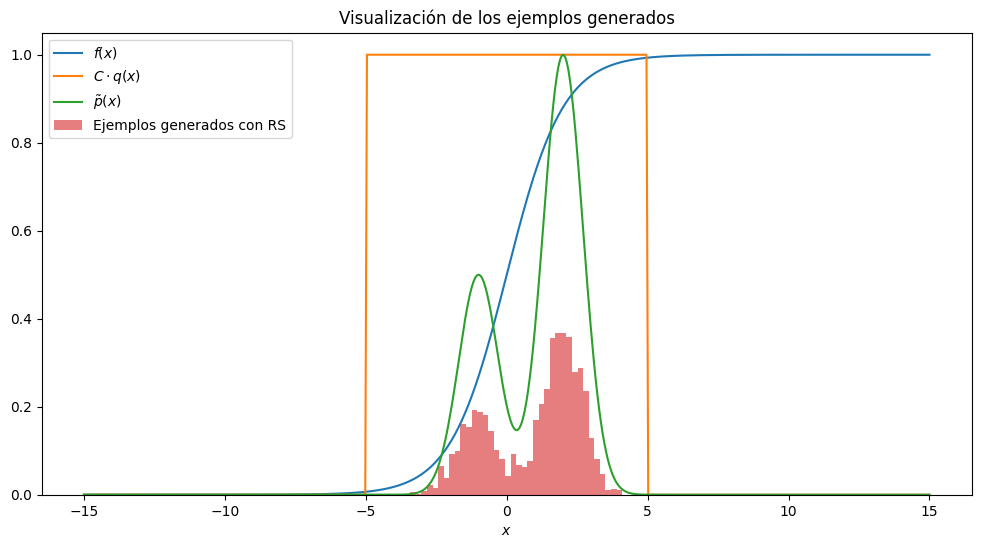

In [226]:
def f(x):
    return (1 + np.exp(-x))**(-1)

y_f = f(x)

plt.figure(figsize=(12, 6))
plt.plot(x, y_f, label=r"$f(x)$")
plt.plot(x, y_C_q, label=r"$C \cdot q(x)$")
plt.plot(x, y_p_tilde, label=r"$\tilde{p}(x)$")
plt.hist(p_samples, bins=40, density=True, alpha=0.6, label="Ejemplos generados con RS")
plt.xlabel(r"$x$")
plt.title(r"Visualización de los ejemplos generados")
plt.legend()
plt.show()

In [227]:
E_f = np.mean(f(p_samples))
print(f"- La estimación del valor esperado de f(x) con x ~ p es: {E_f}")

- La estimación del valor esperado de f(x) con x ~ p es: 0.6647628666267308


5. ¿Cuál es el porcentaje de muestras rechazadas?

In [228]:
def rejected_ratio(f, Cq_pdf, num_samples):
    num_accepted = 0
    num_rejected = 0
    while num_accepted < num_samples:
        x_i = np.random.uniform(-5, 5)
        u = np.random.uniform(0, max(Cq_pdf))
        if u < f(x_i):
            num_accepted += 1
        else:
            num_rejected += 1
    
    return (num_rejected / (num_rejected + num_samples))

ratios = []
for _ in range(20):
    ratio = rejected_ratio(f, y_C_q, N)
    ratios.append(ratio)
ratios = np.array(ratios)
print(f"- De media se rechaza un {(np.mean(ratios) * 100):.1f}% de las muestras generadas.")

- De media se rechaza un 50.1% de las muestras generadas.
